Дана частично наблюдаемая матрица $M \in \mathbb{R}^{m \times n}$ и множество наблюдаемых индексов $\Omega$. Оператор проекции:

$$
(P_\Omega(X))_{ij} = \begin{cases} X_{ij}, & (i,j) \in \Omega \\ 0, & (i,j) \notin \Omega \end{cases}
$$

$$
\min_{X} \; \frac12 \|P_\Omega(X - M)\|_F^2 + \lambda \|X\|_*
$$

где $\|X\|_*$ — ядерная норма.

Вводим $Z = X$ и получаем эквивалентную задачу:

$$
\min_{X,Z} \; \frac12 \|P_\Omega(Z - M)\|_F^2 + \lambda \|X\|_* \quad \text{s.t.} \quad X - Z = 0
$$

$$
L_\rho(X, Z, Y) = \frac12 \|P_\Omega(Z - M)\|_F^2 + \lambda \|X\|_* + \langle Y, X - Z \rangle + \frac{\rho}{2} \|X - Z\|_F^2
$$

где $Y$ — матрица двойственных переменных, $\rho > 0$ — штрафной параметр.

Фиксируем $Z^k, Y^k$ и минимизируем по $X$:

$$
X^{k+1} = \arg\min_X \; \lambda \|X\|_* + \langle Y^k, X \rangle + \frac{\rho}{2} \|X - Z^k\|_F^2
$$

$$
X^{k+1} = \arg\min_X \; \lambda \|X\|_* + \frac{\rho}{2} \left\| X - \left( Z^k - \frac{Y^k}{\rho} \right) \right\|_F^2
$$

Решение: singular‑value soft‑thresholding:

$$
X^{k+1} = S_{\lambda/\rho}\left( Z^k - \frac{Y^k}{\rho} \right)
$$

где для $A = U \Sigma V^\top$:

$$
S_\tau(A) = U \cdot \text{soft}(\Sigma, \tau) \cdot V^\top, \quad \text{soft}(\sigma, \tau) = \max(0, \sigma - \tau)
$$

Фиксируем $X^{k+1}, Y^k$ и минимизируем по $Z$:

$$
Z^{k+1} = \arg\min_Z \; \frac12 \|P_\Omega(Z - M)\|_F^2 - \langle Y^k, Z \rangle + \frac{\rho}{2} \|X^{k+1} - Z\|_F^2
$$

Приравниваем производную к нулю. Рассматриваем два случая:

На позициях $\Omega$:

$$
(Z_{ij} - M_{ij}) - Y_{ij}^k - \rho (X_{ij}^{k+1} - Z_{ij}) = 0
$$

$$
Z_{ij} + \rho Z_{ij} = M_{ij} + Y_{ij}^k + \rho X_{ij}^{k+1}
$$

$$
Z_{ij} = \frac{M_{ij} + Y_{ij}^k + \rho X_{ij}^{k+1}}{1 + \rho}
$$

На позициях $\Omega^\perp$:

$$
0 - Y_{ij}^k - \rho (X_{ij}^{k+1} - Z_{ij}) = 0
$$

$$
Z_{ij} = X_{ij}^{k+1} + \frac{Y_{ij}^k}{\rho}
$$

Объединяем:

$$
Z^{k+1} = P_\Omega\left( \frac{M + Y^k + \rho X^{k+1}}{1 + \rho} \right) + P_{\Omega^\perp}\left( X^{k+1} + \frac{Y^k}{\rho} \right)
$$

$$
Y^{k+1} = Y^k + \rho (X^{k+1} - Z^{k+1})
$$

Первичная невязка:

$$
r_p^{k+1} = \|X^{k+1} - Z^{k+1}\|_F
$$

Двойственная невязка:

$$
r_d^{k+1} = \rho \|Z^{k+1} - Z^k\|_F
$$

Правило остановки:

$$
\max(r_p^{k+1}, r_d^{k+1}) \leq \varepsilon, \quad \varepsilon = 10^{-3}
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
m, n, r = 50, 40, 3
U = np.random.randn(m, r)
V = np.random.randn(n, r)
M_star = U @ V.T
mask = np.random.rand(m, n) < 0.3
noise = 0.01 * np.random.randn(m, n)
M = mask * (M_star + noise)
lambda_ = 1 / np.sqrt(max(m, n))

def svt(A, tau):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    s_thresh = np.maximum(s - tau, 0)
    return U @ np.diag(s_thresh) @ Vt

def admm_matrix_completion(M, mask, lambda_, rho, max_iter=500, tol=1e-3):
    m, n = M.shape
    X = np.zeros((m, n))
    Z = np.zeros((m, n))
    Y = np.zeros((m, n))

    objective = []
    rel_error = []
    residuals = []

    for k in range(max_iter):
        X = svt(Z - Y/rho, lambda_/rho)

        Z_omega = (M + Y + rho * X) / (1 + rho)
        Z_omega_perp = X + Y / rho
        Z = mask * Z_omega + (1 - mask) * Z_omega_perp

        Y = Y + rho * (X - Z)

        obj = 0.5 * np.sum((mask * (Z - M))**2) + lambda_ * np.sum(np.linalg.svd(X, compute_uv=False))
        objective.append(obj)

        err = np.linalg.norm(X - M_star, 'fro') / np.linalg.norm(M_star, 'fro')
        rel_error.append(err)

        rp = np.linalg.norm(X - Z, 'fro')
        rd = rho * np.linalg.norm(Z - (mask * Z_omega + (1 - mask) * Z_omega_perp) if k > 0 else Z, 'fro')
        residuals.append(max(rp, rd))

        if k % 20 == 0:
            print(f"Iter {k}: obj={obj:.4f}, err={err:.4f}, res={max(rp, rd):.4f}")

        if max(rp, rd) < tol:
            print(f"Converged at iteration {k}")
            break

    return X, objective, rel_error, residuals

rhos = [0.1, 1.0, 10.0]
results = {}

for rho in rhos:
    print(f"\n=== Running ADMM with rho = {rho} ===")
    X_rec, obj, err, res = admm_matrix_completion(M, mask, lambda_, rho)
    results[rho] = {'X': X_rec, 'obj': obj, 'err': err, 'res': res}

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for rho in rhos:
    plt.plot(results[rho]['obj'], label=f'ρ={rho}')
plt.xlabel('Iteration')
plt.ylabel('Objective')
plt.title('Objective value vs iteration')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
for rho in rhos:
    plt.plot(results[rho]['err'], label=f'ρ={rho}')
plt.xlabel('Iteration')
plt.ylabel('Relative error')
plt.title('Reconstruction error vs iteration')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
for rho in rhos:
    plt.plot(results[rho]['res'], label=f'ρ={rho}')
plt.xlabel('Iteration')
plt.ylabel('Residual')
plt.title('Primal/dual residual vs iteration')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n=== Final results ===")
for rho in rhos:
    final_err = results[rho]['err'][-1]
    final_obj = results[rho]['obj'][-1]
    final_res = results[rho]['res'][-1]
    print(f"ρ={rho}: final error={final_err:.6f}, final obj={final_obj:.6f}, final res={final_res:.6f}")


=== Running ADMM with rho = 0.1 ===
Iter 0: obj=6.3054, err=1.0000, res=35.5116
Iter 20: obj=19.0223, err=0.5903, res=0.1603
Iter 40: obj=17.9687, err=0.4463, res=0.1001
Iter 60: obj=17.6156, err=0.3547, res=0.0522
Iter 80: obj=17.4831, err=0.2950, res=0.0332
Iter 100: obj=17.4290, err=0.2566, res=0.0212
Iter 120: obj=17.4066, err=0.2321, res=0.0138
Iter 140: obj=17.3974, err=0.2166, res=0.0090
Iter 160: obj=17.3935, err=0.2071, res=0.0058
Iter 180: obj=17.3920, err=0.2013, res=0.0036
Iter 200: obj=17.3914, err=0.1978, res=0.0022
Iter 220: obj=17.3911, err=0.1957, res=0.0014
Converged at iteration 232

=== Running ADMM with rho = 1.0 ===
Iter 0: obj=190.7374, err=1.0000, res=19.5314
Iter 20: obj=23.4891, err=0.8084, res=0.0138
Iter 40: obj=22.2218, err=0.7749, res=0.0045
Iter 60: obj=21.3626, err=0.7452, res=0.0055
Iter 80: obj=20.7578, err=0.7184, res=0.0040
Iter 100: obj=20.3119, err=0.6935, res=0.0026
Iter 120: obj=19.9539, err=0.6704, res=0.0025
Iter 140: obj=19.6580, err=0.6486, 

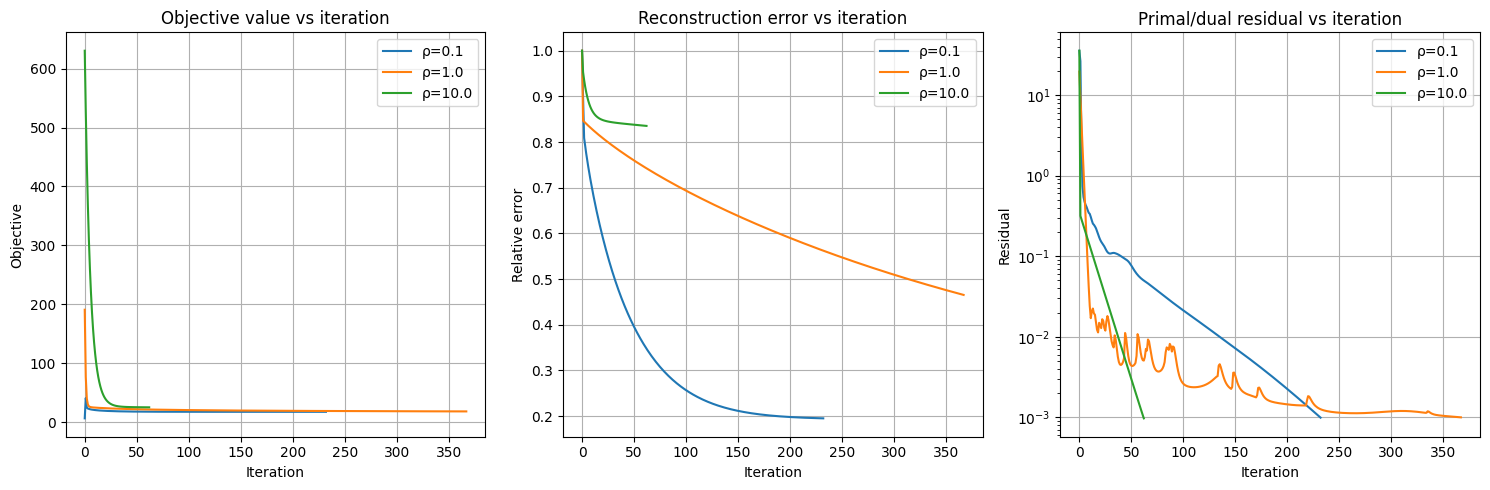


=== Final results ===
ρ=0.1: final error=0.194893, final obj=17.391049, final res=0.000991
ρ=1.0: final error=0.465190, final obj=18.077513, final res=0.001000
ρ=10.0: final error=0.835337, final obj=25.011353, final res=0.000971


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
m, n, r = 50, 40, 3
U = np.random.randn(m, r)
V = np.random.randn(n, r)
M_star = U @ V.T
mask = np.random.rand(m, n) < 0.3
noise = 0.01 * np.random.randn(m, n)
M = mask * (M_star + noise)
lambda_ = 1 / np.sqrt(max(m, n))

def svt(A, tau):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    s_thresh = np.maximum(s - tau, 0)
    return U @ np.diag(s_thresh) @ Vt

def admm_matrix_completion(M, mask, lambda_, rho, max_iter=500, tol=1e-3):
    m, n = M.shape
    X = np.zeros((m, n))
    Z = np.zeros((m, n))
    Y = np.zeros((m, n))

    objective = []
    rel_error = []
    residuals = []

    for k in range(max_iter):
        X = svt(Z - Y/rho, lambda_/rho)

        Z_omega = (M + Y + rho * X) / (1 + rho)
        Z_omega_perp = X + Y / rho
        Z = mask * Z_omega + (1 - mask) * Z_omega_perp

        Y = Y + rho * (X - Z)

        obj = 0.5 * np.sum((mask * (Z - M))**2) + lambda_ * np.sum(np.linalg.svd(X, compute_uv=False))
        objective.append(obj)

        err = np.linalg.norm(X - M_star, 'fro') / np.linalg.norm(M_star, 'fro')
        rel_error.append(err)

        rp = np.linalg.norm(X - Z, 'fro')
        rd = rho * np.linalg.norm(Z - (mask * Z_omega + (1 - mask) * Z_omega_perp) if k > 0 else Z, 'fro')
        residuals.append(max(rp, rd))

        if k % 20 == 0:
            print(f"Iter {k}: obj={obj:.4f}, err={err:.4f}, res={max(rp, rd):.4f}")

        if max(rp, rd) < tol:
            print(f"Converged at iteration {k}")
            break

    return X, objective, rel_error, residuals

rhos = [0.1, 1.0, 10.0]
results = {}

for rho in rhos:
    print(f"\n=== Running ADMM with rho = {rho} ===")
    X_rec, obj, err, res = admm_matrix_completion(M, mask, lambda_, rho)
    results[rho] = {'X': X_rec, 'obj': obj, 'err': err, 'res': res}

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for rho in rhos:
    plt.plot(results[rho]['obj'], label=f'ρ={rho}')
plt.xlabel('Iteration')
plt.ylabel('Objective')
plt.title('Objective value vs iteration')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
for rho in rhos:
    plt.plot(results[rho]['err'], label=f'ρ={rho}')
plt.xlabel('Iteration')
plt.ylabel('Relative error')
plt.title('Reconstruction error vs iteration')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
for rho in rhos:
    plt.plot(results[rho]['res'], label=f'ρ={rho}')
plt.xlabel('Iteration')
plt.ylabel('Residual')
plt.title('Primal/dual residual vs iteration')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n=== Final results ===")
for rho in rhos:
    final_err = results[rho]['err'][-1]
    final_obj = results[rho]['obj'][-1]
    final_res = results[rho]['res'][-1]
    print(f"ρ={rho}: final error={final_err:.6f}, final obj={final_obj:.6f}, final res={final_res:.6f}")

Маленькое ρ обеспечивает наилучшее качество восстановления (ошибка 0.195), так как сингулярные числа сильнее зануляются и ранг итератов ниже, но сходимость медленнее из-за слабой связи между X и Z. Большое ρ ускоряет сходимость (62 итерации), но ухудшает точность (ошибка 0.835), так как SVT ослабляется и ранг итератов остаётся выше, что приводит к переобучению на шум. Теория ADMM подтверждает это.